In [1]:
!pip install librosa audiomentations kaggle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 22.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive, files
drive.mount('/content/drive')

# Upload your kaggle.json first
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d ejlok1/cremad -p /content/crema --unzip

Mounted at /content/drive


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
100% 451M/451M [00:12<00:00, 37.8MB/s]



In [3]:
import os, glob, re, random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
AUDIO_DIR   = "/content/crema/AudioWAV"
SR          = 22050
DURATION    = 3.0       # seconds to pad/trim to
N_MELS      = 128
N_FFT       = 2048
HOP_LENGTH  = 512
MAX_LEN     = 128       # time frames
BATCH_SIZE  = 128      # was 64 — more stable gradients
EPOCHS      = 60
LR          = 5e-4     # was 1e-3 — less aggressive start
NUM_CLASSES = 6

# CREMA-D label map from filename code
LABEL_MAP = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad"
}

In [5]:
import pandas as pd

def parse_cremad_filename(path):
    fname = os.path.basename(path)
    parts = fname.replace(".wav","").split("_")
    # Format: ActorID_SentenceID_Emotion_Intensity
    emotion_code = parts[2]
    return LABEL_MAP.get(emotion_code, None)

audio_files = glob.glob(os.path.join(AUDIO_DIR, "*.wav"))
print(f"Found {len(audio_files)} audio files")

data = []
for f in audio_files:
    label = parse_cremad_filename(f)
    if label:
        data.append({"path": f, "label": label})

df = pd.DataFrame(data)
print(df["label"].value_counts())

Found 7442 audio files
label
sad        1271
angry      1271
disgust    1271
fear       1271
happy      1271
neutral    1087
Name: count, dtype: int64


In [6]:
def load_audio(path, sr=SR, duration=DURATION):
    """Load and pad/trim audio to fixed length."""
    y, _ = librosa.load(path, sr=sr, duration=duration)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode="constant")
    else:
        y = y[:target_len]
    return y

def extract_features(y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, max_len=MAX_LEN):
    """
    Returns a (3, n_mels, max_len) array:
      ch0 = mel spectrogram (dB)
      ch1 = delta
      ch2 = delta-delta
    """
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    delta  = librosa.feature.delta(mel_db, order=1)
    delta2 = librosa.feature.delta(mel_db, order=2)

    def pad_or_trim(feat):
        if feat.shape[1] < max_len:
            feat = np.pad(feat, ((0,0),(0, max_len - feat.shape[1])), mode="constant")
        return feat[:, :max_len]

    mel_db  = pad_or_trim(mel_db)
    delta   = pad_or_trim(delta)
    delta2  = pad_or_trim(delta2)

    # Normalize each channel to [-1, 1]
    def norm(x):
        mn, mx = x.min(), x.max()
        return (x - mn) / (mx - mn + 1e-8) * 2 - 1

    return np.stack([norm(mel_db), norm(delta), norm(delta2)], axis=0).astype(np.float32)

In [7]:
def augment_audio(y, sr=SR):
    """
    Lighter augmentation — only ONE transform, applied with 50% probability each.
    Preserves clean signal for faster learning.
    """
    # 50% chance of any augmentation at all
    if random.random() < 0.5:
        return y

    def time_shift(y):
        shift = int(sr * random.uniform(-0.1, 0.1))  # reduced from ±200ms to ±100ms
        return np.roll(y, shift)

    def add_noise(y):
        noise_amp = random.uniform(0.001, 0.004) * np.max(np.abs(y))  # halved noise
        return y + noise_amp * np.random.randn(len(y))

    def vol_scale(y):
        return y * random.uniform(0.85, 1.15)  # tighter range

    def pitch_shift(y):
        n_steps = random.uniform(-1.5, 1.5)   # reduced from ±2
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

    fn = random.choice([time_shift, add_noise, vol_scale, pitch_shift])
    try:
        y = fn(y)
    except Exception:
        pass
    return y.astype(np.float32)

In [8]:
class CremaDataset(Dataset):
    def __init__(self, df, augment=False):
        self.paths   = df["path"].tolist()
        self.labels  = df["label_enc"].tolist()
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        y = load_audio(self.paths[idx])
        if self.augment:
            y = augment_audio(y)
        feat = extract_features(y)
        feat = torch.tensor(feat)

        # SpecAugment: only applied 40% of the time, smaller masks
        if self.augment and random.random() < 0.4:
            feat = self._spec_augment(feat)

        return feat, self.labels[idx]

    def _spec_augment(self, feat, F=8, T=12):  # reduced mask sizes
        feat = feat.clone()
        f0 = random.randint(0, N_MELS - F)
        feat[:, f0:f0+F, :] = 0
        t0 = random.randint(0, MAX_LEN - T)
        feat[:, :, t0:t0+T] = 0
        return feat

In [9]:
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print("Classes:", list(le.classes_))

train_df, test_df = train_test_split(df, test_size=0.15, stratify=df["label_enc"], random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.12, stratify=train_df["label_enc"], random_state=SEED)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_ds = CremaDataset(train_df, augment=True)
val_ds   = CremaDataset(val_df,   augment=False)
test_ds  = CremaDataset(test_df,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']
Train: 5566 | Val: 759 | Test: 1117


In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True, dropout=0.25):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class EmotionCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Input: (B, 3, 128, 128)
        self.enc = nn.Sequential(
            ConvBlock(3,   64,  pool=True,  dropout=0.1),   # → (64, 64, 64)
            ConvBlock(64,  128, pool=True,  dropout=0.2),   # → (128, 32, 32)
            ConvBlock(128, 256, pool=True,  dropout=0.25),  # → (256, 16, 16)
            ConvBlock(256, 256, pool=True,  dropout=0.25),  # → (256, 8, 8)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.head(self.pool(self.enc(x)))


model = EmotionCNN().to(device)
print("Model re-initialised")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,}")

Model re-initialised
Parameters: 2,461,638


Run 1 — saving everything to: /content/drive/MyDrive/cremad_checkpoints/run1
Epoch   TrLoss   TrAcc   VaLoss   VaAcc         LR
-------------------------------------------------------
    1   1.6084  33.31%   1.5804  37.42%   5.00e-04 best
    2   1.5458  37.48%   1.8168  27.80%   5.00e-04
    3   1.5118  39.62%   1.4352  44.93%   5.00e-04 best
    4   1.4976  40.55%   1.4447  44.66%   5.00e-04
    5   1.4790  41.36%   1.4847  40.71%   5.00e-04
    6   1.4530  43.44%   1.4098  46.11%   5.00e-04 best
    7   1.4412  44.29%   1.3961  46.64%   5.00e-04 best
    8   1.4240  45.10%   1.4063  45.45%   5.00e-04
    9   1.4159  45.78%   1.3833  48.22%   5.00e-04 best
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run1/epoch010.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/val_acc_ep010.png


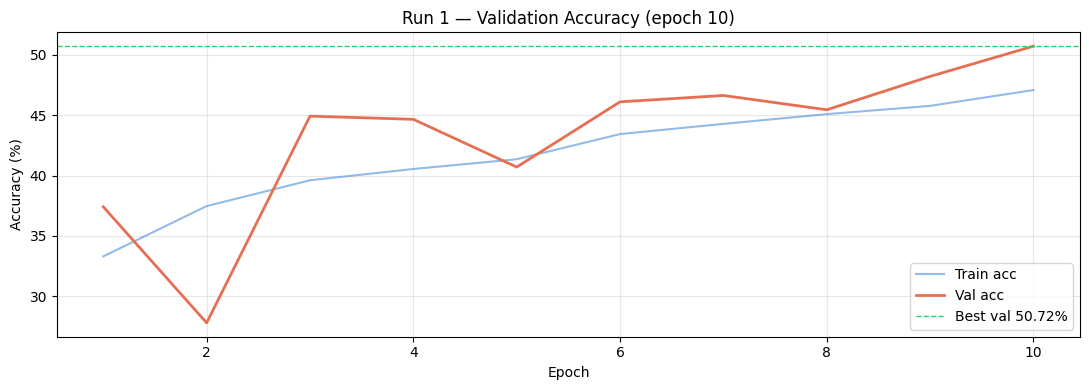

   10   1.3841  47.09%   1.3525  50.72%   5.00e-04 best
   11   1.3820  46.96%   1.3684  49.14%   5.00e-04
   12   1.3657  48.13%   1.3622  48.35%   5.00e-04
   13   1.3519  48.19%   1.3903  44.66%   5.00e-04
   14   1.3441  48.87%   1.3095  52.04%   5.00e-04 best
   15   1.3339  49.71%   1.4327  46.11%   5.00e-04
   16   1.3204  50.23%   1.3349  49.28%   5.00e-04
   17   1.3065  51.62%   1.2783  55.07%   5.00e-04 best
   18   1.3028  51.89%   1.2807  53.75%   5.00e-04
   19   1.2942  52.64%   1.2960  54.02%   5.00e-04
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run1/epoch020.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/val_acc_ep020.png


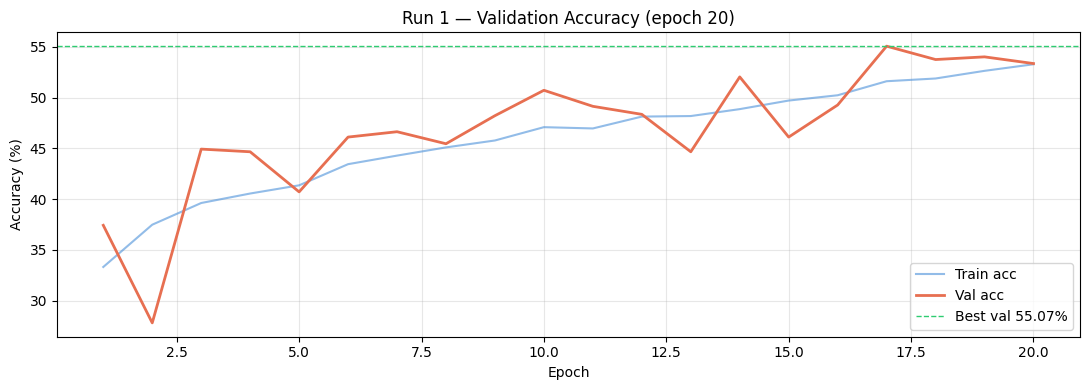

   20   1.2788  53.29%   1.2918  53.36%   5.00e-04
   21   1.2675  53.84%   1.2712  54.81%   2.50e-04
   22   1.2459  54.74%   1.2158  56.65%   2.50e-04 best
   23   1.2332  55.39%   1.2253  57.71%   2.50e-04 best
   24   1.2242  55.86%   1.2402  55.20%   2.50e-04
   25   1.2118  55.98%   1.2132  56.26%   2.50e-04
   26   1.1971  57.38%   1.1838  58.23%   2.50e-04 best
   27   1.2018  56.83%   1.2091  56.52%   2.50e-04
   28   1.1927  57.13%   1.1660  59.29%   2.50e-04 best
   29   1.1849  58.30%   1.2307  56.52%   2.50e-04
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run1/epoch030.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/val_acc_ep030.png


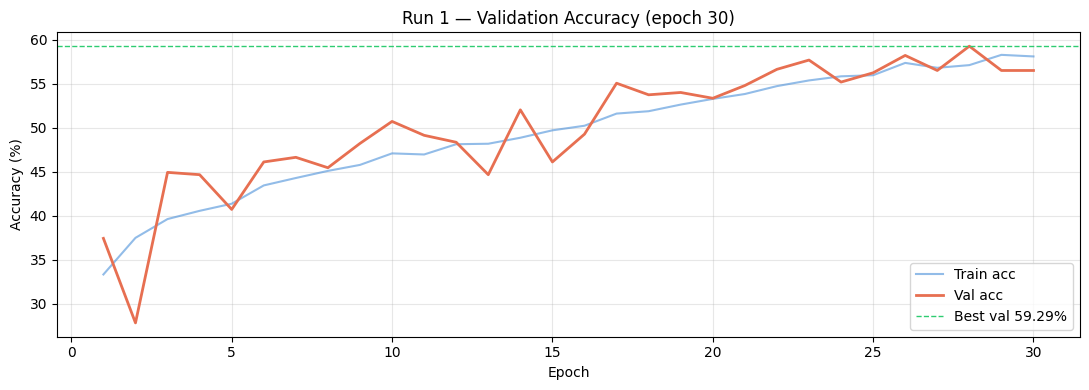

   30   1.1837  58.12%   1.1974  56.52%   2.50e-04
   31   1.1644  58.71%   1.1689  58.37%   2.50e-04
   32   1.1700  59.52%   1.1470  58.37%   1.25e-04
   33   1.1409  60.06%   1.1338  59.68%   1.25e-04 best
   34   1.1296  60.91%   1.1407  58.76%   1.25e-04
   35   1.1188  61.37%   1.1692  57.71%   1.25e-04
   36   1.1065  61.44%   1.1384  58.37%   1.25e-04
   37   1.1003  61.71%   1.1542  59.68%   6.25e-05
   38   1.0883  62.52%   1.1348  59.42%   6.25e-05
   39   1.0945  62.95%   1.1275  60.21%   6.25e-05 best
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run1/epoch040.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/val_acc_ep040.png


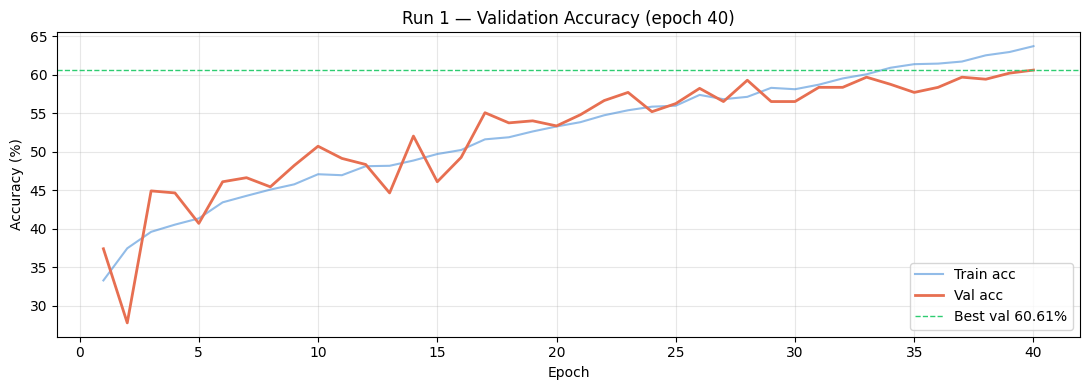

   40   1.0767  63.71%   1.1171  60.61%   6.25e-05 best
   41   1.0759  63.98%   1.1152  60.47%   6.25e-05
   42   1.0670  64.05%   1.1236  60.34%   6.25e-05
   43   1.0659  63.60%   1.1123  59.55%   6.25e-05
   44   1.0499  64.84%   1.1174  60.61%   3.13e-05
   45   1.0550  63.83%   1.1110  61.26%   3.13e-05 best
   46   1.0494  64.34%   1.1058  61.00%   3.13e-05
   47   1.0465  64.18%   1.1119  61.00%   3.13e-05
   48   1.0477  64.91%   1.1119  60.74%   3.13e-05
   49   1.0533  64.21%   1.1056  61.66%   3.13e-05 best
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run1/epoch050.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/val_acc_ep050.png


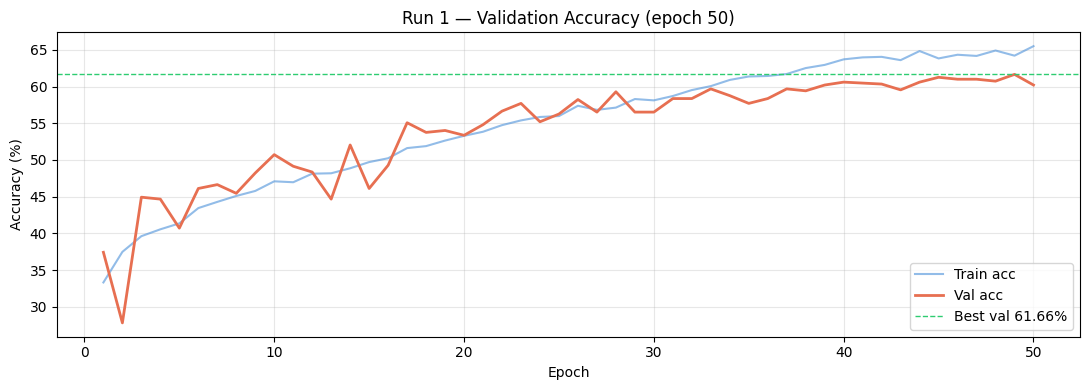

   50   1.0313  65.50%   1.1043  60.21%   3.13e-05
   51   1.0380  64.95%   1.1076  60.87%   3.13e-05
   52   1.0328  65.36%   1.1056  60.47%   3.13e-05
   53   1.0257  65.45%   1.1064  61.66%   1.56e-05
   54   1.0303  65.47%   1.1124  61.40%   1.56e-05
   55   1.0128  66.01%   1.1054  61.53%   1.56e-05
   56   1.0207  65.54%   1.1052  61.92%   1.56e-05 best
   57   1.0174  66.53%   1.1054  61.13%   1.56e-05
   58   1.0204  65.43%   1.1062  61.26%   1.56e-05
   59   1.0107  66.06%   1.0981  61.66%   1.56e-05
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run1/epoch060.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/val_acc_ep060.png


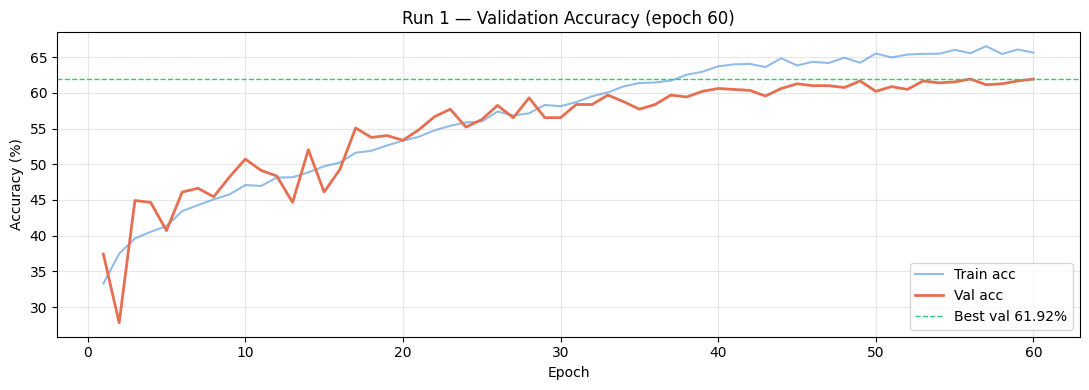

   60   1.0192  65.63%   1.1025  61.92%   7.81e-06
   61   1.0140  66.30%   1.1036  60.87%   7.81e-06
   62   1.0075  67.01%   1.1035  61.13%   7.81e-06
   63   1.0094  66.58%   1.1040  61.26%   7.81e-06
   64   1.0199  65.92%   1.1022  61.26%   3.91e-06
   65   1.0108  66.71%   1.1026  61.13%   3.91e-06
   66   1.0021  67.14%   1.1028  61.26%   3.91e-06
   67   1.0041  66.37%   1.1022  61.79%   3.91e-06
   68   1.0120  66.37%   1.1022  61.40%   1.95e-06
   69   1.0114  65.94%   1.1025  61.92%   1.95e-06
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run1/epoch070.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/val_acc_ep070.png


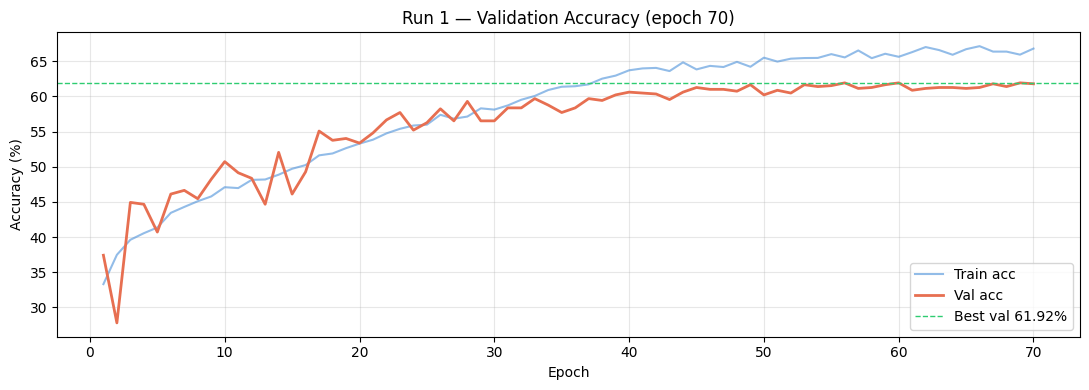

   70   1.0126  66.80%   1.1026  61.79%   1.95e-06
   71   1.0069  66.06%   1.1038  61.79%   1.95e-06
   72   1.0072  66.67%   1.1051  62.32%   1.95e-06 best
   73   1.0099  66.89%   1.1018  60.87%   1.95e-06
   74   1.0201  65.86%   1.1013  61.53%   1.95e-06
   75   1.0047  67.37%   1.1029  61.79%   1.95e-06
   76   1.0110  66.76%   1.1019  61.40%   1.00e-06
   77   1.0123  66.82%   1.1014  61.26%   1.00e-06
   78   1.0086  66.49%   1.1011  61.53%   1.00e-06
   79   1.0049  66.13%   1.1007  61.40%   1.00e-06
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run1/epoch080.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/val_acc_ep080.png


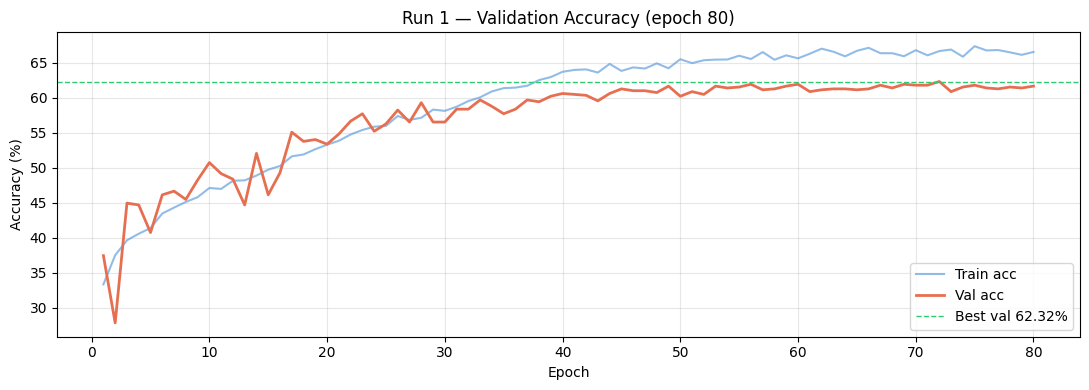

   80   1.0050  66.55%   1.1008  61.66%   1.00e-06

  RUN 1 SUMMARY
  Best val accuracy  : 62.32%  (epoch 72)
  Final val accuracy : 61.66%  (epoch 80)
  Plateau evidence   : peaked at epoch 72, then stabilised over remaining 8 epochs

Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run1/run1_val_acc_FINAL.png


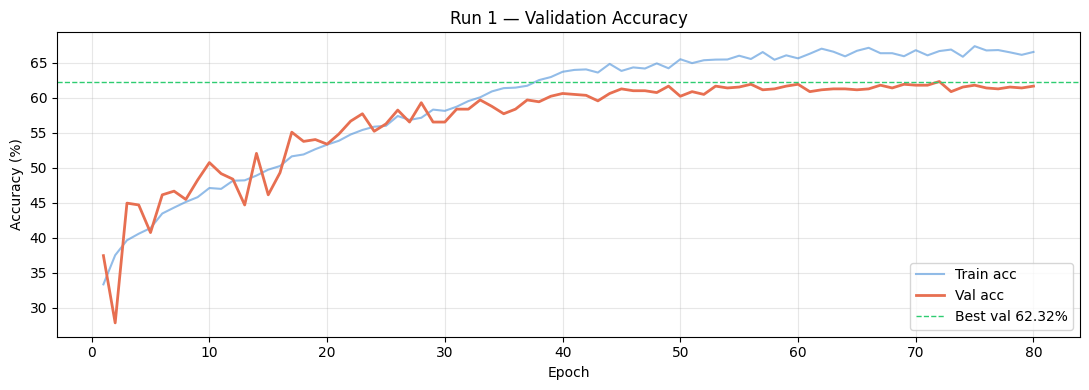

Confusion matrix saved → /content/drive/MyDrive/cremad_checkpoints/run1/run1_confusion_matrix.png


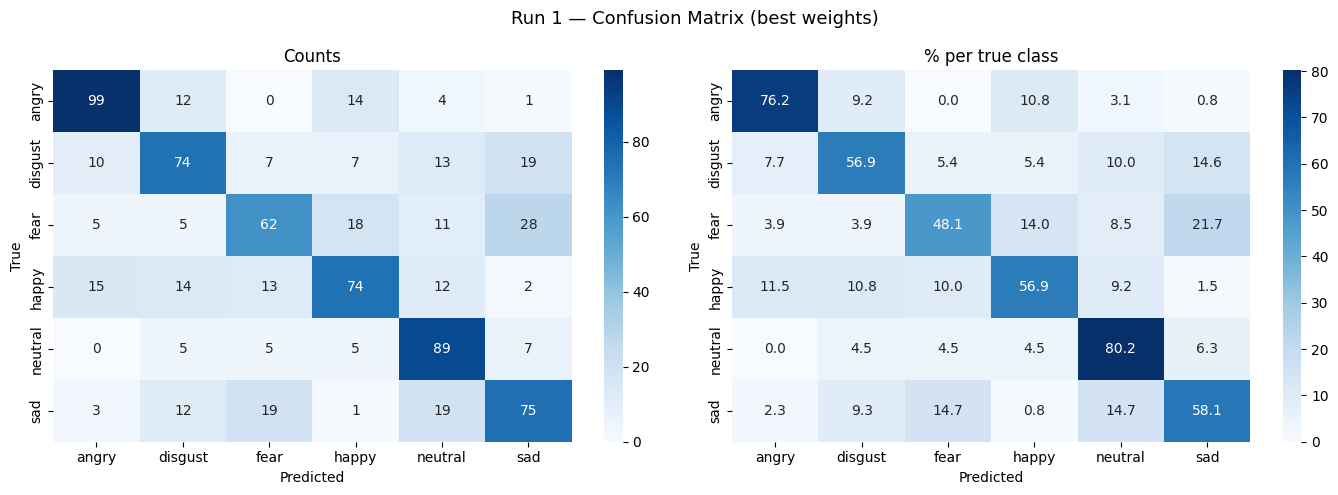

Best model weights saved → /content/drive/MyDrive/cremad_checkpoints/run1/run1_BEST_MODEL.pth
History saved → /content/drive/MyDrive/cremad_checkpoints/run1/run1_history.json
Confusion matrix array saved/content/drive/MyDrive/cremad_checkpoints/run1/run1_confusion_matrix.npy

Run 1 complete. All files in: /content/drive/MyDrive/cremad_checkpoints/run1


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import json

EPOCHS = 80
RUN_ID = 1
CHECKPOINT_DIR = f"/content/drive/MyDrive/cremad_checkpoints/run{RUN_ID}"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Run {RUN_ID} — saving everything to: {CHECKPOINT_DIR}")

def save_checkpoint(epoch, val_acc, tag=""):
    path = os.path.join(CHECKPOINT_DIR, f"epoch{epoch:03d}{tag}.pth")
    torch.save({
        "run_id":        RUN_ID,
        "epoch":         epoch,
        "model_state":   model.state_dict(),
        "optimizer":     optimizer.state_dict(),
        "scheduler":     scheduler.state_dict(),
        "val_acc":       val_acc,
        "history":       history,
        "label_classes": list(le.classes_),
    }, path)
    print(f"Checkpoint saved{path}")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total

def plot_and_save_val_accuracy(history, best_val_acc, epoch=None, save_path=None):
    epochs_so_far = range(1, len(history["val_acc"]) + 1)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(epochs_so_far, [a * 100 for a in history["train_acc"]],
            color="#4A90D9", linewidth=1.5, alpha=0.6, label="Train acc")
    ax.plot(epochs_so_far, [a * 100 for a in history["val_acc"]],
            color="#E76F51", linewidth=2.0, label="Val acc")
    ax.axhline(best_val_acc * 100, color="#2ecc71", linewidth=1,
               linestyle="--", label=f"Best val {best_val_acc:.2%}")
    title = f"Run {RUN_ID} — Validation Accuracy"
    if epoch:
        title += f" (epoch {epoch})"
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Accuracy plot saved{save_path}")
    plt.show()

def plot_and_save_confusion_matrix(model, loader, class_names, save_path=None):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            preds = model(x.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm     = confusion_matrix(all_labels, all_preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Run {RUN_ID} — Confusion Matrix (best weights)", fontsize=13)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title("Counts")
    axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title("% per true class")
    axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Confusion matrix saved → {save_path}")
    plt.show()

    return cm, cm_pct, all_labels, all_preds
model     = EmotionCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5, min_lr=1e-6
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state = 0.0, None

print(f"{'Epoch':>5} {'TrLoss':>8} {'TrAcc':>7} {'VaLoss':>8} {'VaAcc':>7} {'LR':>10}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    scheduler.step(va_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        tag = " best"
    else:
        tag = ""

    if epoch % 10 == 0:
        save_checkpoint(epoch, va_acc)
        plot_and_save_val_accuracy(history, best_val_acc, epoch=epoch,
            save_path=os.path.join(CHECKPOINT_DIR, f"val_acc_ep{epoch:03d}.png"))

    print(f"{epoch:>5} {tr_loss:>8.4f} {tr_acc:>7.2%} {va_loss:>8.4f} {va_acc:>7.2%} {current_lr:>10.2e}{tag}")

peak_epoch = history["val_acc"].index(best_val_acc) + 1
final_acc  = history["val_acc"][-1]

print(f"\n{'='*55}")
print(f"  RUN {RUN_ID} SUMMARY")
print(f"{'='*55}")
print(f"  Best val accuracy  : {best_val_acc:.2%}  (epoch {peak_epoch})")
print(f"  Final val accuracy : {final_acc:.2%}  (epoch {EPOCHS})")
print(f"  Plateau evidence   : peaked at epoch {peak_epoch}, "
      f"then {'stabilised' if abs(final_acc - best_val_acc) < 0.02 else 'declined'} "
      f"over remaining {EPOCHS - peak_epoch} epochs")
print(f"{'='*55}\n")

plot_and_save_val_accuracy(history, best_val_acc,
    save_path=os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_val_acc_FINAL.png"))

model.load_state_dict(best_state)
model.to(device)
cm, cm_pct, all_labels, all_preds = plot_and_save_confusion_matrix(
    model, val_loader, list(le.classes_),
    save_path=os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_confusion_matrix.png"))

best_model_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_BEST_MODEL.pth")
torch.save({
    "run_id":        RUN_ID,
    "model_state":   best_state,
    "val_acc":       best_val_acc,
    "peak_epoch":    peak_epoch,
    "final_acc":     final_acc,
    "label_classes": list(le.classes_),
}, best_model_path)
print(f"Best model weights saved → {best_model_path}")

history_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_history.json")
with open(history_path, "w") as f:
    json.dump({
        "run_id":      RUN_ID,
        "history":     history,
        "best_val_acc": best_val_acc,
        "peak_epoch":  peak_epoch,
        "final_acc":   final_acc,
        "label_classes": list(le.classes_),
    }, f, indent=2)
print(f"History saved → {history_path}")

# ── Save confusion matrix arrays as .npy (for compile notebook) ──
cm_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_confusion_matrix.npy")
np.save(cm_path, cm)
print(f"Confusion matrix array saved{cm_path}")

print(f"\nRun {RUN_ID} complete. All files in: {CHECKPOINT_DIR}")

Run 2 — saving everything to: /content/drive/MyDrive/cremad_checkpoints/run2
Epoch   TrLoss   TrAcc   VaLoss   VaAcc         LR
-------------------------------------------------------
    1   1.6082  33.22%   1.5776  37.55%   5.00e-04 best
    2   1.5449  37.55%   1.7630  29.78%   5.00e-04
    3   1.5127  39.35%   1.4377  44.80%   5.00e-04 best
    4   1.4964  40.59%   1.4590  42.69%   5.00e-04
    5   1.4812  41.30%   1.4902  40.97%   5.00e-04
    6   1.4560  43.30%   1.4149  45.32%   5.00e-04 best
    7   1.4411  44.32%   1.3921  47.30%   5.00e-04 best
    8   1.4260  44.38%   1.4341  45.45%   5.00e-04
    9   1.4186  45.62%   1.3728  48.88%   5.00e-04 best
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run2/epoch010.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/val_acc_ep010.png


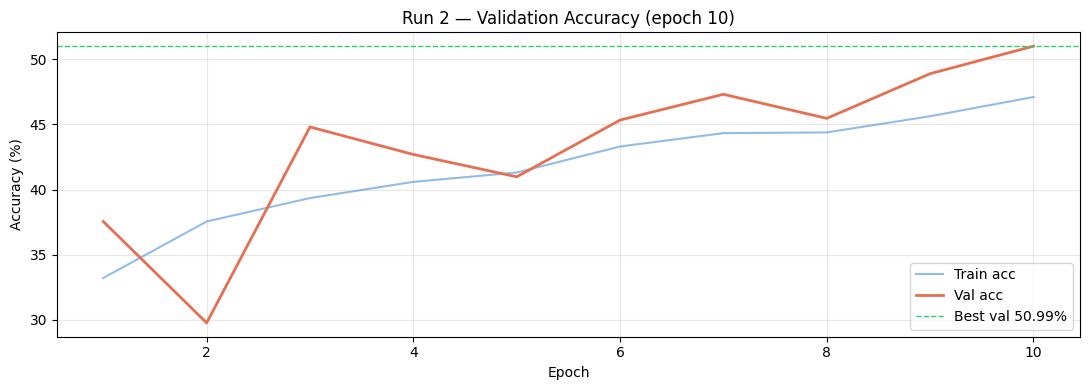

   10   1.3840  47.09%   1.3468  50.99%   5.00e-04 best
   11   1.3850  47.09%   1.3531  48.09%   5.00e-04
   12   1.3666  47.79%   1.3682  48.88%   5.00e-04
   13   1.3561  48.60%   1.3622  48.09%   5.00e-04
   14   1.3447  48.29%   1.3182  51.91%   5.00e-04 best
   15   1.3298  50.52%   1.3710  50.33%   5.00e-04
   16   1.3170  50.54%   1.3342  50.59%   5.00e-04
   17   1.3096  51.15%   1.2751  54.81%   5.00e-04 best
   18   1.3066  51.46%   1.2707  52.83%   5.00e-04
   19   1.2929  52.87%   1.3054  51.91%   5.00e-04
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run2/epoch020.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/val_acc_ep020.png


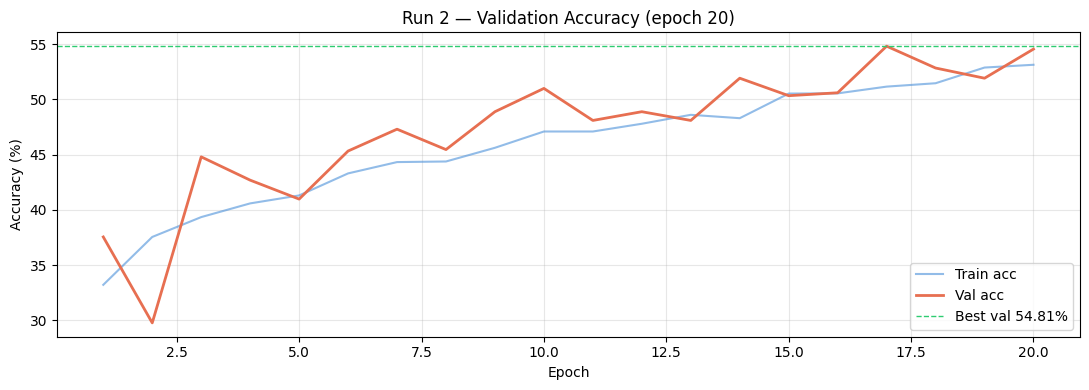

   20   1.2807  53.13%   1.2817  54.55%   5.00e-04
   21   1.2675  53.40%   1.3043  52.57%   2.50e-04
   22   1.2435  54.47%   1.2306  55.86%   2.50e-04 best
   23   1.2333  55.30%   1.2254  56.79%   2.50e-04 best
   24   1.2244  55.66%   1.2295  57.31%   2.50e-04 best
   25   1.2088  56.65%   1.2119  55.99%   2.50e-04
   26   1.1940  57.38%   1.1823  59.42%   2.50e-04 best
   27   1.2026  55.73%   1.2310  56.79%   2.50e-04
   28   1.1883  57.42%   1.1756  57.84%   2.50e-04
   29   1.1832  57.74%   1.2565  54.68%   2.50e-04
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run2/epoch030.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/val_acc_ep030.png


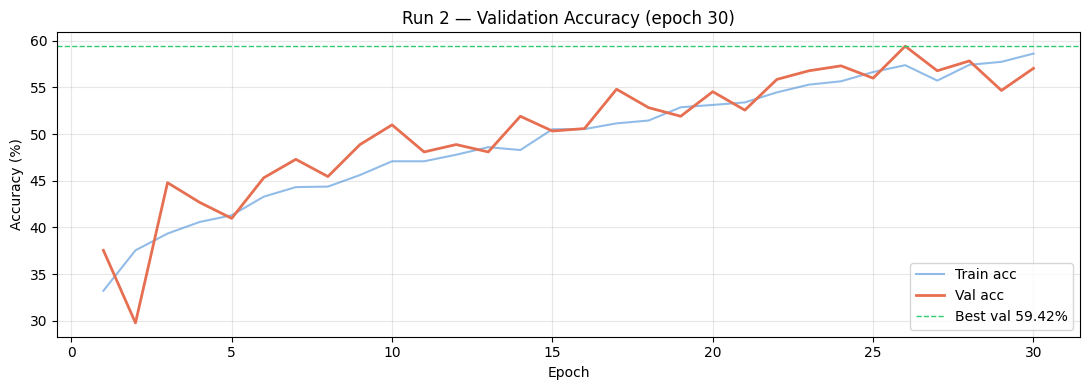

   30   1.1825  58.62%   1.1898  57.05%   1.25e-04
   31   1.1483  59.83%   1.1486  60.34%   1.25e-04 best
   32   1.1487  60.11%   1.1446  58.23%   1.25e-04
   33   1.1301  60.33%   1.1395  59.16%   1.25e-04
   34   1.1272  61.01%   1.1502  59.55%   1.25e-04
   35   1.1180  61.23%   1.1703  58.37%   6.25e-05
   36   1.1007  61.52%   1.1282  59.03%   6.25e-05
   37   1.0975  61.68%   1.1359  59.68%   6.25e-05
   38   1.0911  61.89%   1.1390  59.68%   6.25e-05
   39   1.0995  62.41%   1.1281  59.55%   3.13e-05
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run2/epoch040.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/val_acc_ep040.png


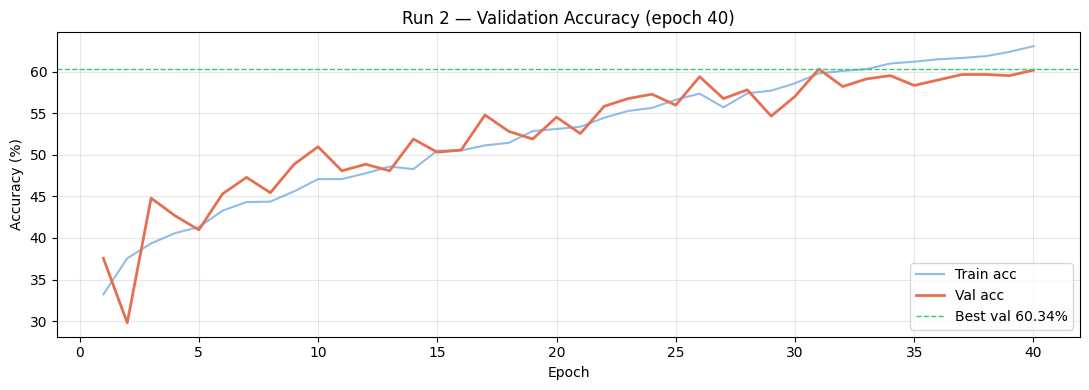

   40   1.0795  63.10%   1.1196  60.21%   3.13e-05
   41   1.0741  63.94%   1.1153  59.95%   3.13e-05
   42   1.0712  63.38%   1.1160  59.95%   3.13e-05
   43   1.0701  63.87%   1.1099  60.08%   1.56e-05
   44   1.0532  64.71%   1.1132  60.61%   1.56e-05 best
   45   1.0633  64.14%   1.1134  60.08%   1.56e-05
   46   1.0570  64.30%   1.1125  59.95%   1.56e-05
   47   1.0613  64.03%   1.1127  61.26%   1.56e-05 best
   48   1.0622  64.16%   1.1158  60.34%   1.56e-05
   49   1.0681  63.08%   1.1126  60.47%   1.56e-05
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run2/epoch050.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/val_acc_ep050.png


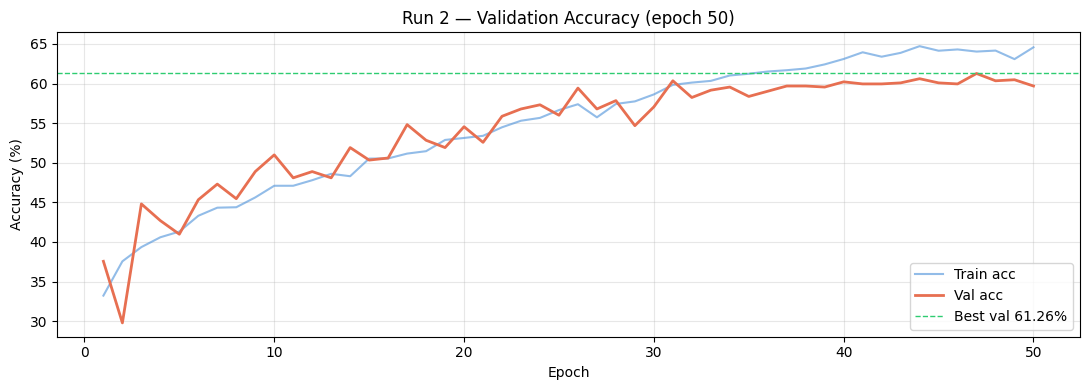

   50   1.0515  64.57%   1.1135  59.68%   1.56e-05
   51   1.0530  64.18%   1.1111  59.82%   7.81e-06
   52   1.0520  64.18%   1.1124  59.55%   7.81e-06
   53   1.0474  64.88%   1.1150  59.42%   7.81e-06
   54   1.0543  63.80%   1.1160  60.21%   7.81e-06
   55   1.0368  65.06%   1.1131  60.47%   3.91e-06
   56   1.0477  64.91%   1.1121  60.61%   3.91e-06
   57   1.0457  65.15%   1.1127  60.74%   3.91e-06
   58   1.0477  64.23%   1.1121  60.21%   3.91e-06
   59   1.0362  64.77%   1.1095  60.47%   1.95e-06
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run2/epoch060.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/val_acc_ep060.png


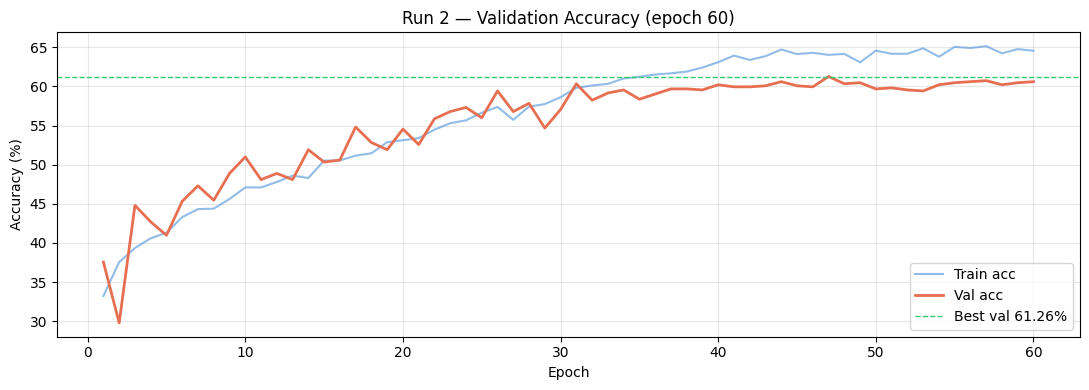

   60   1.0505  64.55%   1.1097  60.61%   1.95e-06
   61   1.0428  64.89%   1.1106  60.08%   1.95e-06
   62   1.0438  64.82%   1.1102  59.82%   1.95e-06
   63   1.0441  64.82%   1.1106  59.95%   1.00e-06
   64   1.0435  64.52%   1.1109  59.95%   1.00e-06
   65   1.0458  64.86%   1.1111  59.95%   1.00e-06
   66   1.0387  65.24%   1.1105  60.34%   1.00e-06
   67   1.0387  64.75%   1.1107  60.34%   1.00e-06
   68   1.0427  64.52%   1.1106  60.47%   1.00e-06
   69   1.0472  64.41%   1.1108  59.95%   1.00e-06
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run2/epoch070.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/val_acc_ep070.png


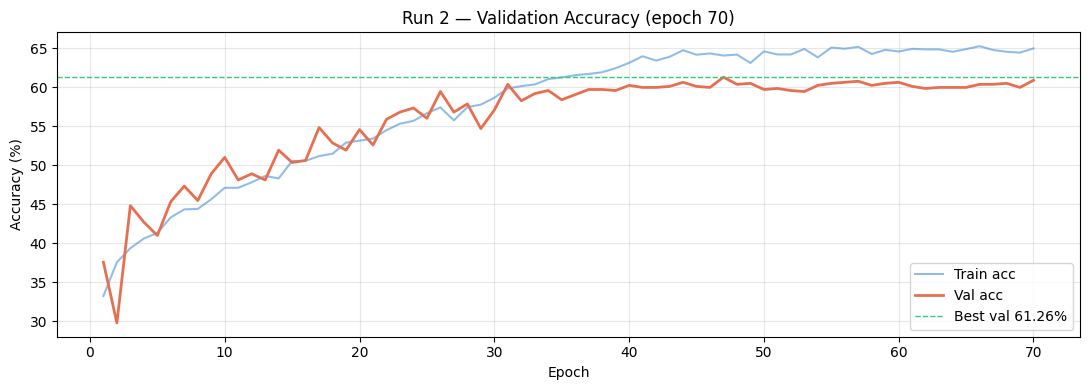

   70   1.0467  64.95%   1.1116  60.87%   1.00e-06
   71   1.0418  64.86%   1.1116  60.61%   1.00e-06
   72   1.0414  64.97%   1.1129  60.61%   1.00e-06
   73   1.0467  65.24%   1.1100  60.08%   1.00e-06
   74   1.0545  64.37%   1.1100  60.47%   1.00e-06
   75   1.0416  65.13%   1.1115  60.34%   1.00e-06
   76   1.0474  65.07%   1.1112  60.74%   1.00e-06
   77   1.0462  65.04%   1.1098  60.47%   1.00e-06
   78   1.0476  64.28%   1.1094  60.61%   1.00e-06
   79   1.0427  64.34%   1.1088  60.21%   1.00e-06
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run2/epoch080.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/val_acc_ep080.png


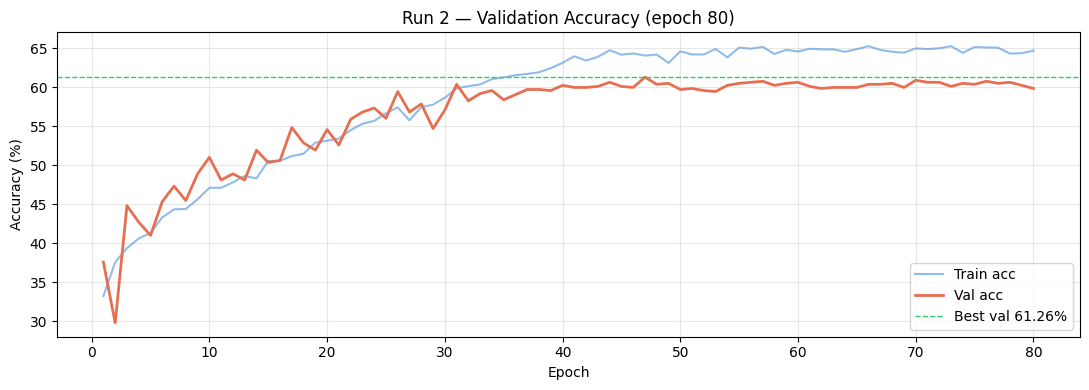

   80   1.0414  64.66%   1.1087  59.82%   1.00e-06

  RUN 2 SUMMARY
  Best val accuracy  : 61.26%  (epoch 47)
  Final val accuracy : 59.82%  (epoch 80)
  Plateau evidence   : peaked at epoch 47, then stabilised over remaining 33 epochs

Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run2/run2_val_acc_FINAL.png


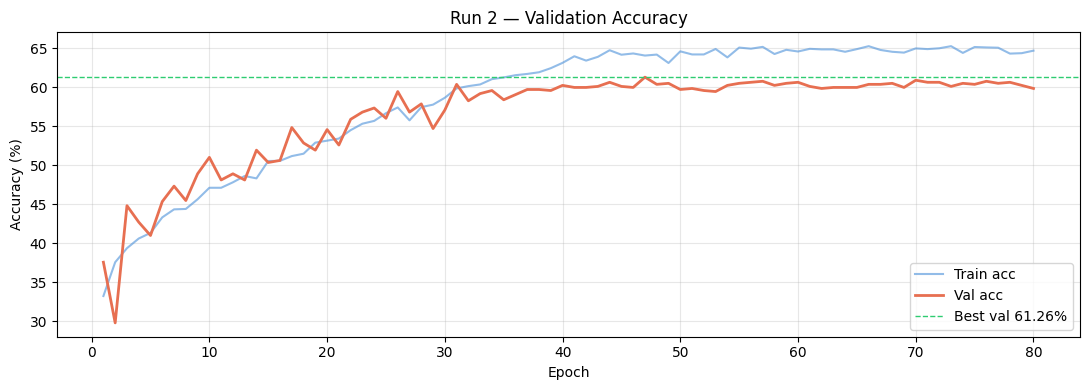

Confusion matrix saved → /content/drive/MyDrive/cremad_checkpoints/run2/run2_confusion_matrix.png


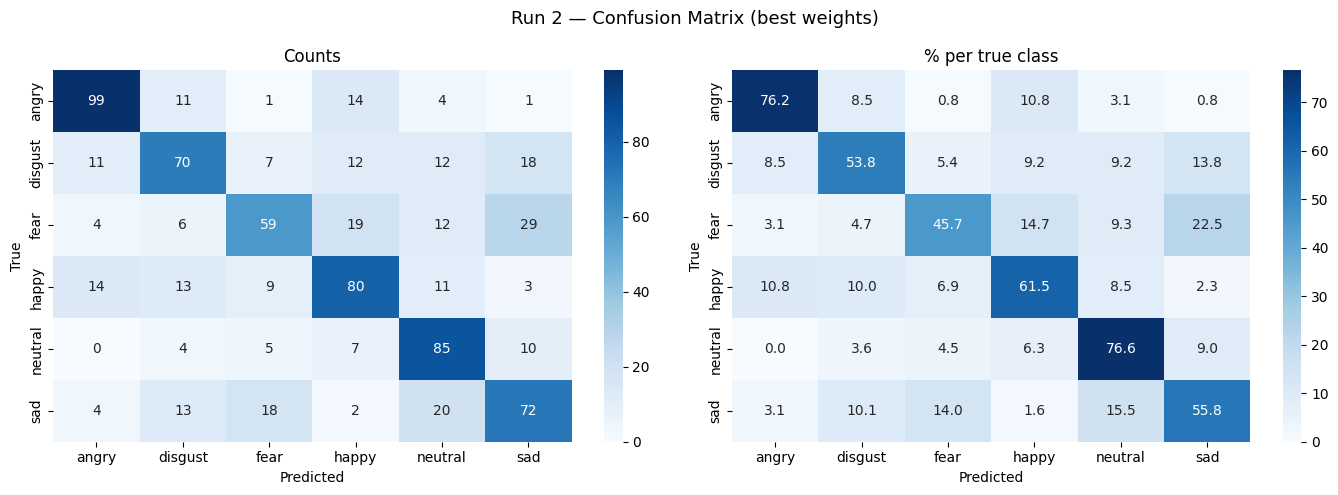

Best model weights saved → /content/drive/MyDrive/cremad_checkpoints/run2/run2_BEST_MODEL.pth
History saved → /content/drive/MyDrive/cremad_checkpoints/run2/run2_history.json
Confusion matrix array saved/content/drive/MyDrive/cremad_checkpoints/run2/run2_confusion_matrix.npy

Run 2 complete. All files in: /content/drive/MyDrive/cremad_checkpoints/run2


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import json

EPOCHS = 80
RUN_ID = 2
CHECKPOINT_DIR = f"/content/drive/MyDrive/cremad_checkpoints/run{RUN_ID}"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Run {RUN_ID} — saving everything to: {CHECKPOINT_DIR}")

def save_checkpoint(epoch, val_acc, tag=""):
    path = os.path.join(CHECKPOINT_DIR, f"epoch{epoch:03d}{tag}.pth")
    torch.save({
        "run_id":        RUN_ID,
        "epoch":         epoch,
        "model_state":   model.state_dict(),
        "optimizer":     optimizer.state_dict(),
        "scheduler":     scheduler.state_dict(),
        "val_acc":       val_acc,
        "history":       history,
        "label_classes": list(le.classes_),
    }, path)
    print(f"Checkpoint saved{path}")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total

def plot_and_save_val_accuracy(history, best_val_acc, epoch=None, save_path=None):
    epochs_so_far = range(1, len(history["val_acc"]) + 1)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(epochs_so_far, [a * 100 for a in history["train_acc"]],
            color="#4A90D9", linewidth=1.5, alpha=0.6, label="Train acc")
    ax.plot(epochs_so_far, [a * 100 for a in history["val_acc"]],
            color="#E76F51", linewidth=2.0, label="Val acc")
    ax.axhline(best_val_acc * 100, color="#2ecc71", linewidth=1,
               linestyle="--", label=f"Best val {best_val_acc:.2%}")
    title = f"Run {RUN_ID} — Validation Accuracy"
    if epoch:
        title += f" (epoch {epoch})"
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Accuracy plot saved{save_path}")
    plt.show()

def plot_and_save_confusion_matrix(model, loader, class_names, save_path=None):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            preds = model(x.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm     = confusion_matrix(all_labels, all_preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Run {RUN_ID} — Confusion Matrix (best weights)", fontsize=13)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title("Counts")
    axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title("% per true class")
    axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Confusion matrix saved → {save_path}")
    plt.show()

    return cm, cm_pct, all_labels, all_preds
model     = EmotionCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5, min_lr=1e-6
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state = 0.0, None

print(f"{'Epoch':>5} {'TrLoss':>8} {'TrAcc':>7} {'VaLoss':>8} {'VaAcc':>7} {'LR':>10}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    scheduler.step(va_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        tag = " best"
    else:
        tag = ""

    if epoch % 10 == 0:
        save_checkpoint(epoch, va_acc)
        plot_and_save_val_accuracy(history, best_val_acc, epoch=epoch,
            save_path=os.path.join(CHECKPOINT_DIR, f"val_acc_ep{epoch:03d}.png"))

    print(f"{epoch:>5} {tr_loss:>8.4f} {tr_acc:>7.2%} {va_loss:>8.4f} {va_acc:>7.2%} {current_lr:>10.2e}{tag}")

peak_epoch = history["val_acc"].index(best_val_acc) + 1
final_acc  = history["val_acc"][-1]

print(f"\n{'='*55}")
print(f"  RUN {RUN_ID} SUMMARY")
print(f"{'='*55}")
print(f"  Best val accuracy  : {best_val_acc:.2%}  (epoch {peak_epoch})")
print(f"  Final val accuracy : {final_acc:.2%}  (epoch {EPOCHS})")
print(f"  Plateau evidence   : peaked at epoch {peak_epoch}, "
      f"then {'stabilised' if abs(final_acc - best_val_acc) < 0.02 else 'declined'} "
      f"over remaining {EPOCHS - peak_epoch} epochs")
print(f"{'='*55}\n")

plot_and_save_val_accuracy(history, best_val_acc,
    save_path=os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_val_acc_FINAL.png"))

model.load_state_dict(best_state)
model.to(device)
cm, cm_pct, all_labels, all_preds = plot_and_save_confusion_matrix(
    model, val_loader, list(le.classes_),
    save_path=os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_confusion_matrix.png"))

best_model_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_BEST_MODEL.pth")
torch.save({
    "run_id":        RUN_ID,
    "model_state":   best_state,
    "val_acc":       best_val_acc,
    "peak_epoch":    peak_epoch,
    "final_acc":     final_acc,
    "label_classes": list(le.classes_),
}, best_model_path)
print(f"Best model weights saved → {best_model_path}")

history_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_history.json")
with open(history_path, "w") as f:
    json.dump({
        "run_id":      RUN_ID,
        "history":     history,
        "best_val_acc": best_val_acc,
        "peak_epoch":  peak_epoch,
        "final_acc":   final_acc,
        "label_classes": list(le.classes_),
    }, f, indent=2)
print(f"History saved → {history_path}")

# ── Save confusion matrix arrays as .npy (for compile notebook) ──
cm_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_confusion_matrix.npy")
np.save(cm_path, cm)
print(f"Confusion matrix array saved{cm_path}")

print(f"\nRun {RUN_ID} complete. All files in: {CHECKPOINT_DIR}")

Run 3 — saving everything to: /content/drive/MyDrive/cremad_checkpoints/run3
Epoch   TrLoss   TrAcc   VaLoss   VaAcc         LR
-------------------------------------------------------
    1   1.6081  33.35%   1.5700  37.81%   5.00e-04 best
    2   1.5451  37.57%   1.8130  28.72%   5.00e-04
    3   1.5134  39.33%   1.4370  45.45%   5.00e-04 best
    4   1.4975  40.59%   1.4377  44.66%   5.00e-04
    5   1.4795  41.50%   1.4844  41.37%   5.00e-04
    6   1.4542  43.71%   1.4056  46.51%   5.00e-04 best
    7   1.4431  43.64%   1.3917  47.04%   5.00e-04 best
    8   1.4236  44.57%   1.4207  45.32%   5.00e-04
    9   1.4185  45.72%   1.3699  49.01%   5.00e-04 best
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run3/epoch010.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/val_acc_ep010.png


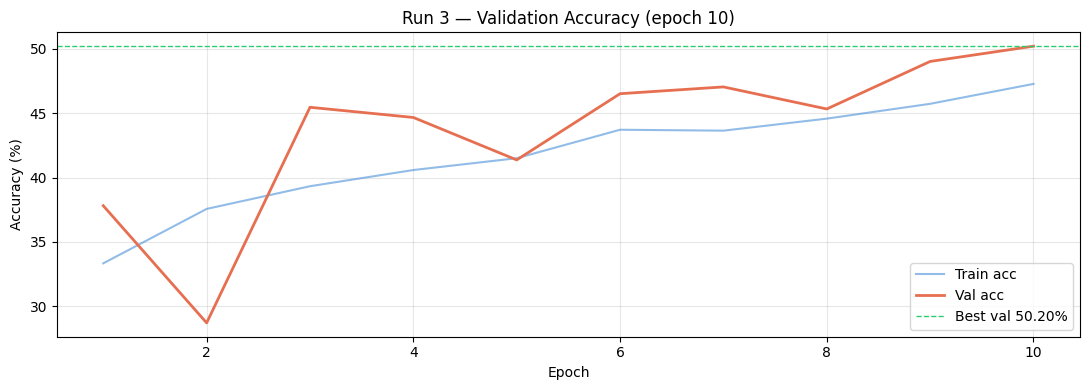

   10   1.3834  47.27%   1.3533  50.20%   5.00e-04 best
   11   1.3815  46.98%   1.3588  48.75%   5.00e-04
   12   1.3616  48.38%   1.3694  49.01%   5.00e-04
   13   1.3541  48.98%   1.3740  45.98%   5.00e-04
   14   1.3451  48.60%   1.3043  53.49%   5.00e-04 best
   15   1.3255  50.86%   1.3500  52.31%   5.00e-04
   16   1.3172  50.14%   1.3122  51.38%   5.00e-04
   17   1.3039  51.74%   1.2685  55.60%   5.00e-04 best
   18   1.3043  51.67%   1.2697  54.02%   5.00e-04
   19   1.2864  53.20%   1.2806  55.34%   5.00e-04
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run3/epoch020.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/val_acc_ep020.png


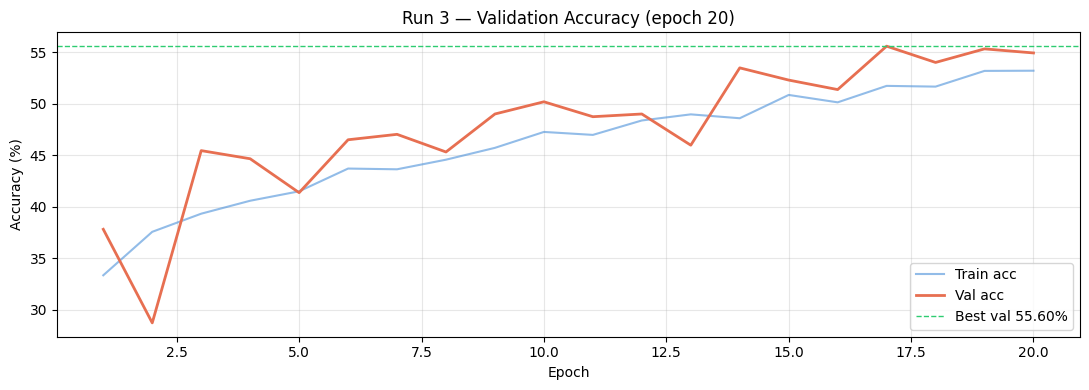

   20   1.2766  53.22%   1.2640  54.94%   5.00e-04
   21   1.2639  54.44%   1.3034  52.57%   2.50e-04
   22   1.2428  55.23%   1.2111  56.65%   2.50e-04 best
   23   1.2297  55.84%   1.2418  56.52%   2.50e-04
   24   1.2197  55.68%   1.2217  56.52%   2.50e-04
   25   1.2047  56.45%   1.2096  56.65%   2.50e-04
   26   1.1919  57.74%   1.1804  59.82%   2.50e-04 best
   27   1.1945  57.04%   1.2006  57.31%   2.50e-04
   28   1.1857  57.96%   1.1724  58.37%   2.50e-04
   29   1.1805  57.98%   1.2431  56.13%   2.50e-04
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run3/epoch030.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/val_acc_ep030.png


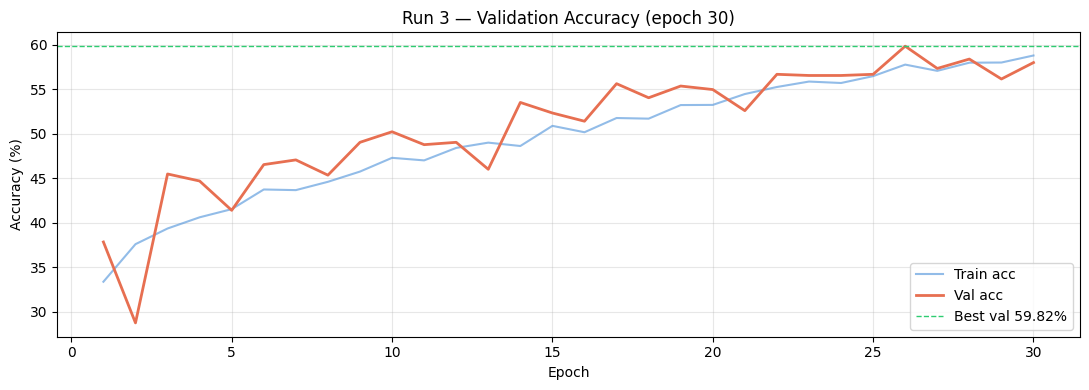

   30   1.1775  58.77%   1.1790  57.97%   1.25e-04
   31   1.1440  59.61%   1.1473  60.21%   1.25e-04 best
   32   1.1451  60.42%   1.1488  57.71%   1.25e-04
   33   1.1248  61.09%   1.1357  59.42%   1.25e-04
   34   1.1229  61.16%   1.1430  60.34%   1.25e-04 best
   35   1.1149  61.23%   1.1657  57.71%   1.25e-04
   36   1.1001  61.82%   1.1548  58.63%   1.25e-04
   37   1.0954  62.00%   1.1471  60.47%   1.25e-04 best
   38   1.0923  62.06%   1.1791  58.23%   1.25e-04
   39   1.1056  62.45%   1.1381  60.08%   1.25e-04
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run3/epoch040.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/val_acc_ep040.png


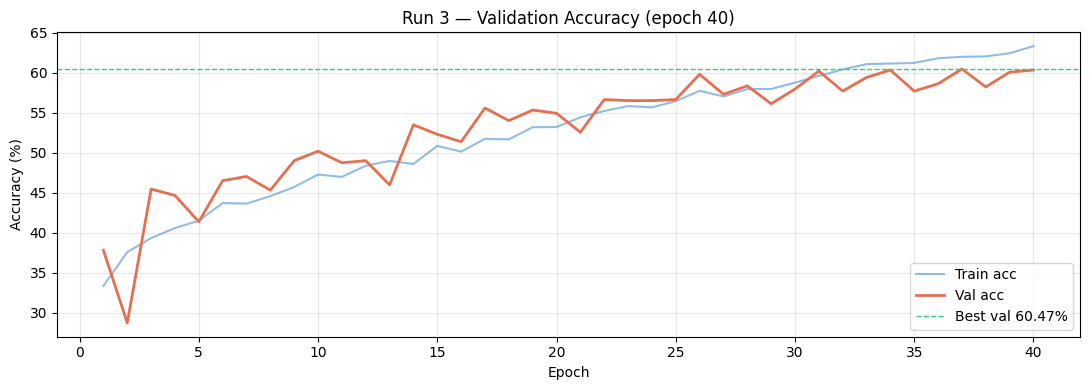

   40   1.0826  63.33%   1.1143  60.34%   1.25e-04
   41   1.0800  63.64%   1.1187  61.13%   1.25e-04 best
   42   1.0734  63.62%   1.1262  59.29%   1.25e-04
   43   1.0695  63.85%   1.1423  58.76%   1.25e-04
   44   1.0546  63.73%   1.1588  58.63%   1.25e-04
   45   1.0649  63.82%   1.1327  61.26%   1.25e-04 best
   46   1.0565  64.41%   1.1197  60.47%   1.25e-04
   47   1.0490  64.77%   1.1170  61.00%   1.25e-04
   48   1.0477  64.88%   1.1325  59.29%   1.25e-04
   49   1.0501  64.09%   1.1166  61.26%   6.25e-05
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run3/epoch050.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/val_acc_ep050.png


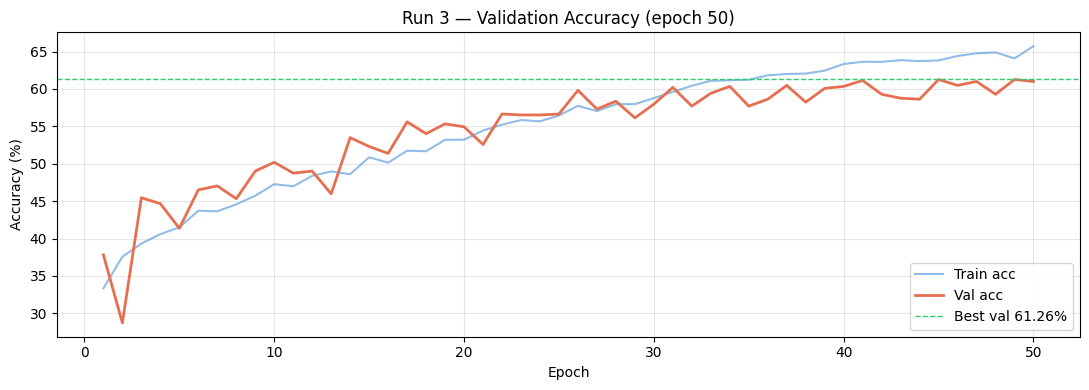

   50   1.0180  65.72%   1.0980  61.00%   6.25e-05
   51   1.0122  66.67%   1.0983  61.26%   6.25e-05
   52   1.0119  66.10%   1.0920  60.21%   6.25e-05
   53   0.9977  67.14%   1.0974  61.92%   6.25e-05 best
   54   1.0025  66.44%   1.0929  61.26%   6.25e-05
   55   0.9816  67.34%   1.0916  61.40%   6.25e-05
   56   0.9846  67.64%   1.1072  61.53%   6.25e-05
   57   0.9853  67.95%   1.0926  61.66%   3.13e-05
   58   0.9733  67.98%   1.0843  61.79%   3.13e-05
   59   0.9590  68.54%   1.0822  61.66%   3.13e-05
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run3/epoch060.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/val_acc_ep060.png


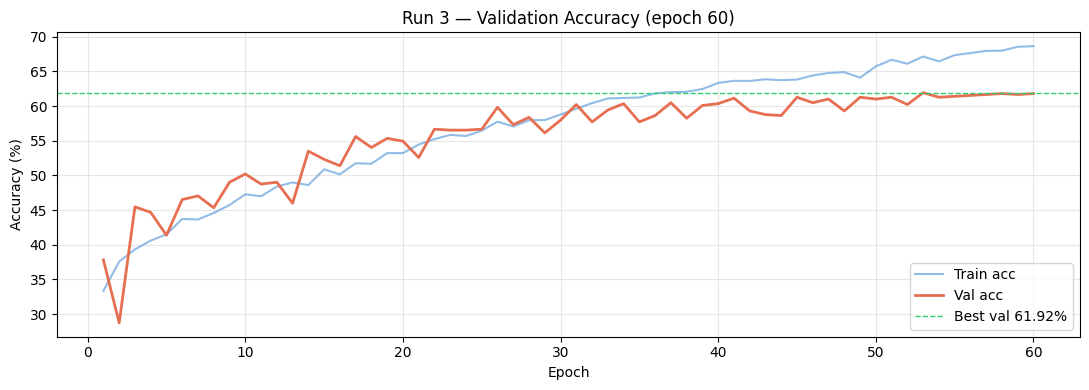

   60   0.9641  68.63%   1.0854  61.79%   3.13e-05
   61   0.9614  69.17%   1.0877  62.58%   3.13e-05 best
   62   0.9515  69.35%   1.0903  62.45%   3.13e-05
   63   0.9514  69.22%   1.0829  62.06%   3.13e-05
   64   0.9583  69.26%   1.0913  62.19%   3.13e-05
   65   0.9554  68.74%   1.0873  62.32%   1.56e-05
   66   0.9425  69.69%   1.0857  62.71%   1.56e-05 best
   67   0.9425  69.69%   1.0788  63.11%   1.56e-05 best
   68   0.9425  69.62%   1.0830  62.45%   1.56e-05
   69   0.9442  69.60%   1.0858  62.32%   1.56e-05
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run3/epoch070.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/val_acc_ep070.png


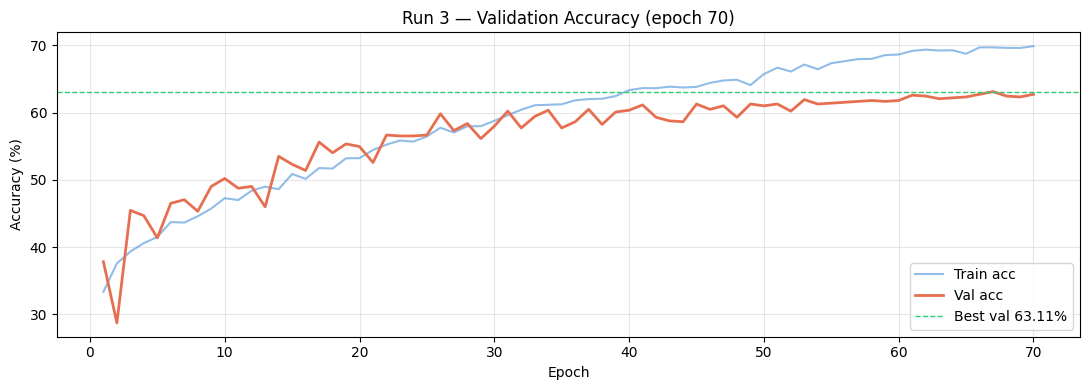

   70   0.9469  69.87%   1.0847  62.71%   1.56e-05
   71   0.9371  70.21%   1.0810  62.45%   7.81e-06
   72   0.9325  70.25%   1.0840  62.32%   7.81e-06
   73   0.9347  70.12%   1.0796  62.85%   7.81e-06
   74   0.9410  69.28%   1.0804  62.45%   7.81e-06
   75   0.9333  70.10%   1.0795  62.71%   3.91e-06
   76   0.9366  70.57%   1.0794  62.85%   3.91e-06
   77   0.9295  70.89%   1.0793  63.11%   3.91e-06
   78   0.9371  69.48%   1.0786  62.71%   3.91e-06
   79   0.9274  70.23%   1.0794  62.98%   1.95e-06
Checkpoint saved/content/drive/MyDrive/cremad_checkpoints/run3/epoch080.pth
Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/val_acc_ep080.png


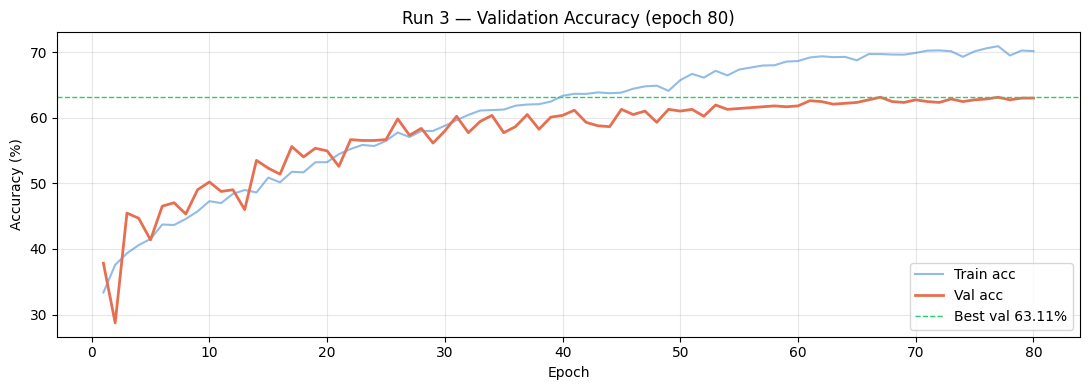

   80   0.9273  70.14%   1.0794  62.98%   1.95e-06

  RUN 3 SUMMARY
  Best val accuracy  : 63.11%  (epoch 67)
  Final val accuracy : 62.98%  (epoch 80)
  Plateau evidence   : peaked at epoch 67, then stabilised over remaining 13 epochs

Accuracy plot saved/content/drive/MyDrive/cremad_checkpoints/run3/run3_val_acc_FINAL.png


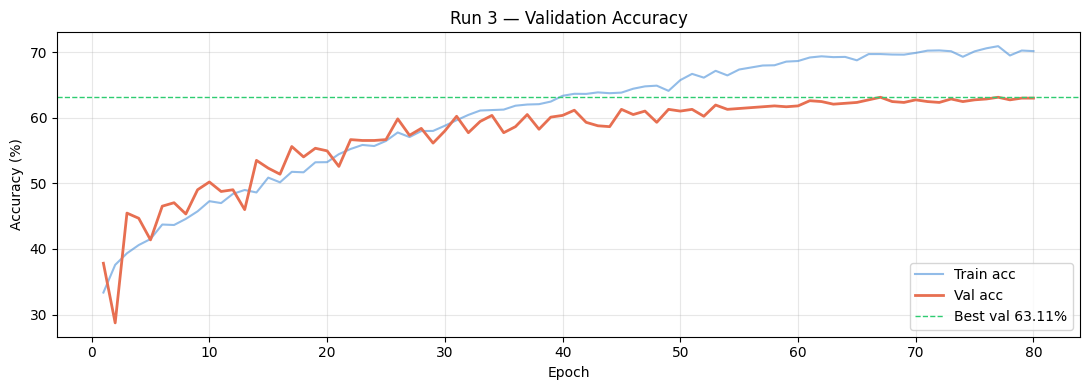

Confusion matrix saved → /content/drive/MyDrive/cremad_checkpoints/run3/run3_confusion_matrix.png


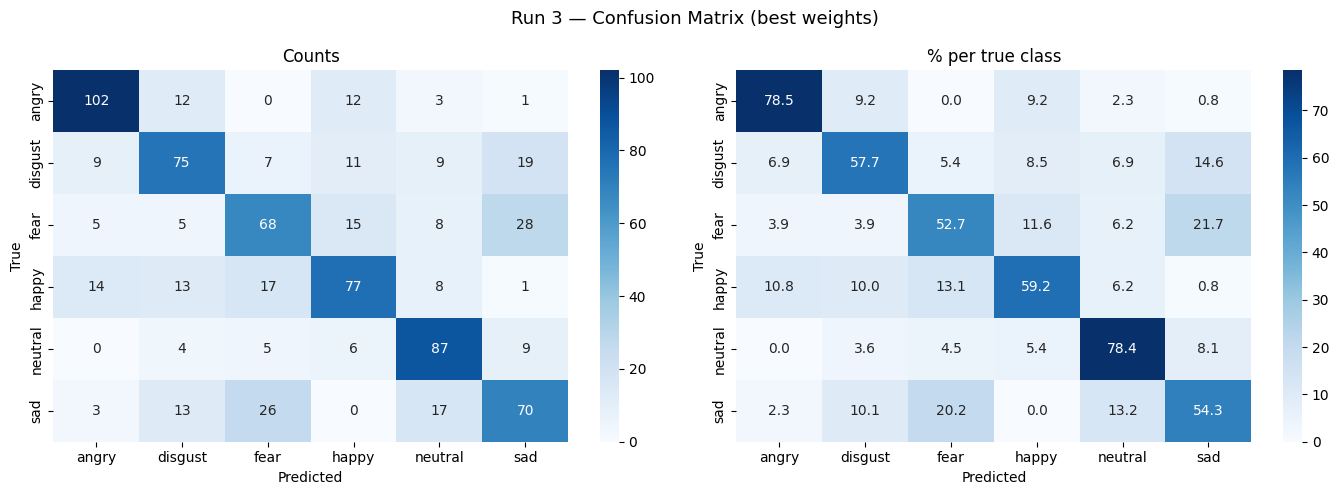

Best model weights saved → /content/drive/MyDrive/cremad_checkpoints/run3/run3_BEST_MODEL.pth
History saved → /content/drive/MyDrive/cremad_checkpoints/run3/run3_history.json
Confusion matrix array saved/content/drive/MyDrive/cremad_checkpoints/run3/run3_confusion_matrix.npy

Run 3 complete. All files in: /content/drive/MyDrive/cremad_checkpoints/run3


In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import json

EPOCHS = 80
RUN_ID = 3
CHECKPOINT_DIR = f"/content/drive/MyDrive/cremad_checkpoints/run{RUN_ID}"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Run {RUN_ID} — saving everything to: {CHECKPOINT_DIR}")

def save_checkpoint(epoch, val_acc, tag=""):
    path = os.path.join(CHECKPOINT_DIR, f"epoch{epoch:03d}{tag}.pth")
    torch.save({
        "run_id":        RUN_ID,
        "epoch":         epoch,
        "model_state":   model.state_dict(),
        "optimizer":     optimizer.state_dict(),
        "scheduler":     scheduler.state_dict(),
        "val_acc":       val_acc,
        "history":       history,
        "label_classes": list(le.classes_),
    }, path)
    print(f"Checkpoint saved{path}")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total

def plot_and_save_val_accuracy(history, best_val_acc, epoch=None, save_path=None):
    epochs_so_far = range(1, len(history["val_acc"]) + 1)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(epochs_so_far, [a * 100 for a in history["train_acc"]],
            color="#4A90D9", linewidth=1.5, alpha=0.6, label="Train acc")
    ax.plot(epochs_so_far, [a * 100 for a in history["val_acc"]],
            color="#E76F51", linewidth=2.0, label="Val acc")
    ax.axhline(best_val_acc * 100, color="#2ecc71", linewidth=1,
               linestyle="--", label=f"Best val {best_val_acc:.2%}")
    title = f"Run {RUN_ID} — Validation Accuracy"
    if epoch:
        title += f" (epoch {epoch})"
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Accuracy plot saved{save_path}")
    plt.show()

def plot_and_save_confusion_matrix(model, loader, class_names, save_path=None):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            preds = model(x.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm     = confusion_matrix(all_labels, all_preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Run {RUN_ID} — Confusion Matrix (best weights)", fontsize=13)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title("Counts")
    axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title("% per true class")
    axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Confusion matrix saved → {save_path}")
    plt.show()

    return cm, cm_pct, all_labels, all_preds
model     = EmotionCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5, min_lr=1e-6
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state = 0.0, None

print(f"{'Epoch':>5} {'TrLoss':>8} {'TrAcc':>7} {'VaLoss':>8} {'VaAcc':>7} {'LR':>10}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    scheduler.step(va_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        tag = " best"
    else:
        tag = ""

    if epoch % 10 == 0:
        save_checkpoint(epoch, va_acc)
        plot_and_save_val_accuracy(history, best_val_acc, epoch=epoch,
            save_path=os.path.join(CHECKPOINT_DIR, f"val_acc_ep{epoch:03d}.png"))

    print(f"{epoch:>5} {tr_loss:>8.4f} {tr_acc:>7.2%} {va_loss:>8.4f} {va_acc:>7.2%} {current_lr:>10.2e}{tag}")

peak_epoch = history["val_acc"].index(best_val_acc) + 1
final_acc  = history["val_acc"][-1]

print(f"\n{'='*55}")
print(f"  RUN {RUN_ID} SUMMARY")
print(f"{'='*55}")
print(f"  Best val accuracy  : {best_val_acc:.2%}  (epoch {peak_epoch})")
print(f"  Final val accuracy : {final_acc:.2%}  (epoch {EPOCHS})")
print(f"  Plateau evidence   : peaked at epoch {peak_epoch}, "
      f"then {'stabilised' if abs(final_acc - best_val_acc) < 0.02 else 'declined'} "
      f"over remaining {EPOCHS - peak_epoch} epochs")
print(f"{'='*55}\n")

plot_and_save_val_accuracy(history, best_val_acc,
    save_path=os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_val_acc_FINAL.png"))

model.load_state_dict(best_state)
model.to(device)
cm, cm_pct, all_labels, all_preds = plot_and_save_confusion_matrix(
    model, val_loader, list(le.classes_),
    save_path=os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_confusion_matrix.png"))

best_model_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_BEST_MODEL.pth")
torch.save({
    "run_id":        RUN_ID,
    "model_state":   best_state,
    "val_acc":       best_val_acc,
    "peak_epoch":    peak_epoch,
    "final_acc":     final_acc,
    "label_classes": list(le.classes_),
}, best_model_path)
print(f"Best model weights saved → {best_model_path}")

history_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_history.json")
with open(history_path, "w") as f:
    json.dump({
        "run_id":      RUN_ID,
        "history":     history,
        "best_val_acc": best_val_acc,
        "peak_epoch":  peak_epoch,
        "final_acc":   final_acc,
        "label_classes": list(le.classes_),
    }, f, indent=2)
print(f"History saved → {history_path}")

# ── Save confusion matrix arrays as .npy (for compile notebook) ──
cm_path = os.path.join(CHECKPOINT_DIR, f"run{RUN_ID}_confusion_matrix.npy")
np.save(cm_path, cm)
print(f"Confusion matrix array saved{cm_path}")

print(f"\nRun {RUN_ID} complete. All files in: {CHECKPOINT_DIR}")

In [12]:
import os

save_path = "/content/drive/MyDrive/cremad_efficientnet_best.pth"

torch.save({
    "model_state":    best_state,
    "val_accuracy":   best_val_acc,
    "label_classes":  le.classes_.tolist(),
    "config": {
        "sr":          SR,
        "n_mels":      N_MELS,
        "n_fft":       N_FFT,
        "hop_length":  HOP_LENGTH,
        "max_len":     MAX_LEN,
        "duration":    DURATION,
        "num_classes": NUM_CLASSES,
    }
}, save_path)

print(f"Saved to: {save_path}")
print(f"Best val accuracy: {best_val_acc:.2%}")

Saved to: /content/drive/MyDrive/cremad_efficientnet_best.pth
Best val accuracy: 63.11%


In [13]:
from google.colab import files

local_path = "/content/cremad_efficientnet_best.pth"
torch.save({
    "model_state":   best_state,
    "val_accuracy":  best_val_acc,
    "label_classes": le.classes_.tolist(),
    "config": {
        "sr":          SR,
        "n_mels":      N_MELS,
        "n_fft":       N_FFT,
        "hop_length":  HOP_LENGTH,
        "max_len":     MAX_LEN,
        "duration":    DURATION,
        "num_classes": NUM_CLASSES,
    }
}, local_path)

files.download(local_path)  # triggers browser download
print("Download started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


Run 1 loaded — best: 62.32% at epoch 72
Run 2 loaded — best: 61.26% at epoch 47
Run 3 loaded — best: 63.11% at epoch 67

ALL 3 RUNS

  Run      Best acc   Peak epoch    Final acc
  --------------------------------------------
  Run 1       62.32%           72       61.66%
  Run 2       61.26%           47       59.82%
  Run 3       63.11%           67       62.98%

  Best val accuracy  — mean: 62.23%  ± std: 0.76%
  Final val accuracy — mean: 61.48%  ± std: 1.30%
  Peak epoch         — mean: 62.0   ± std: 10.8


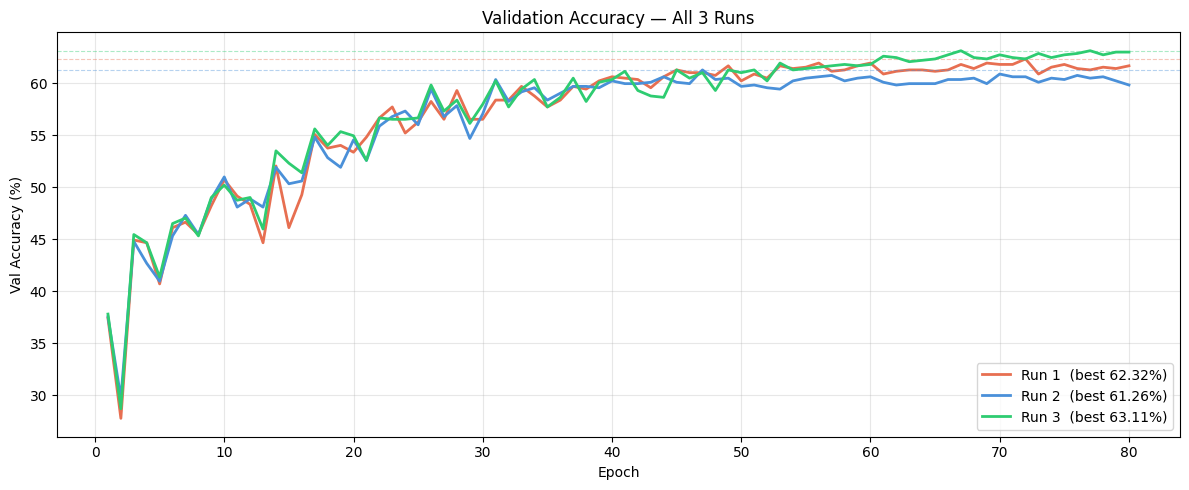

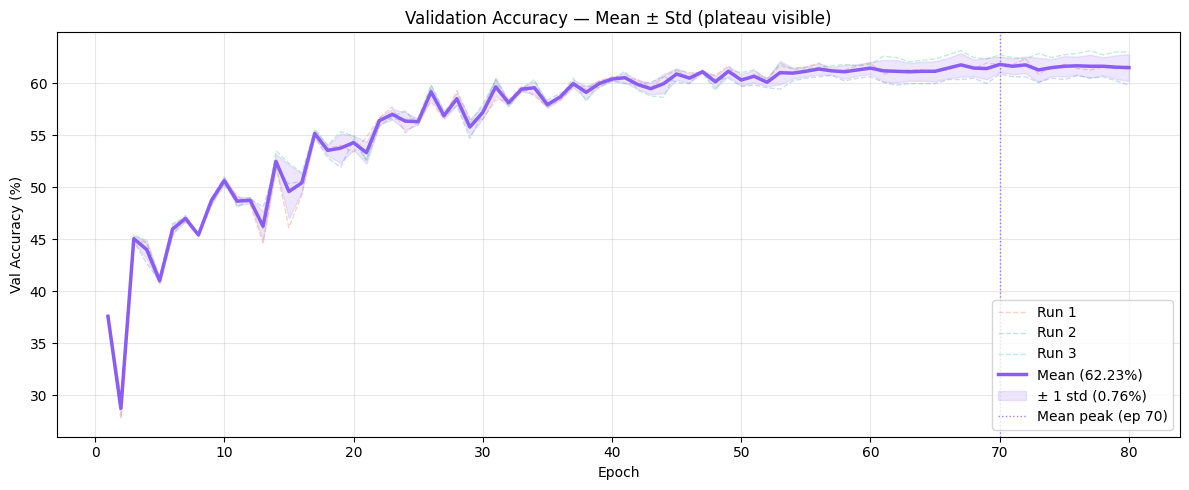

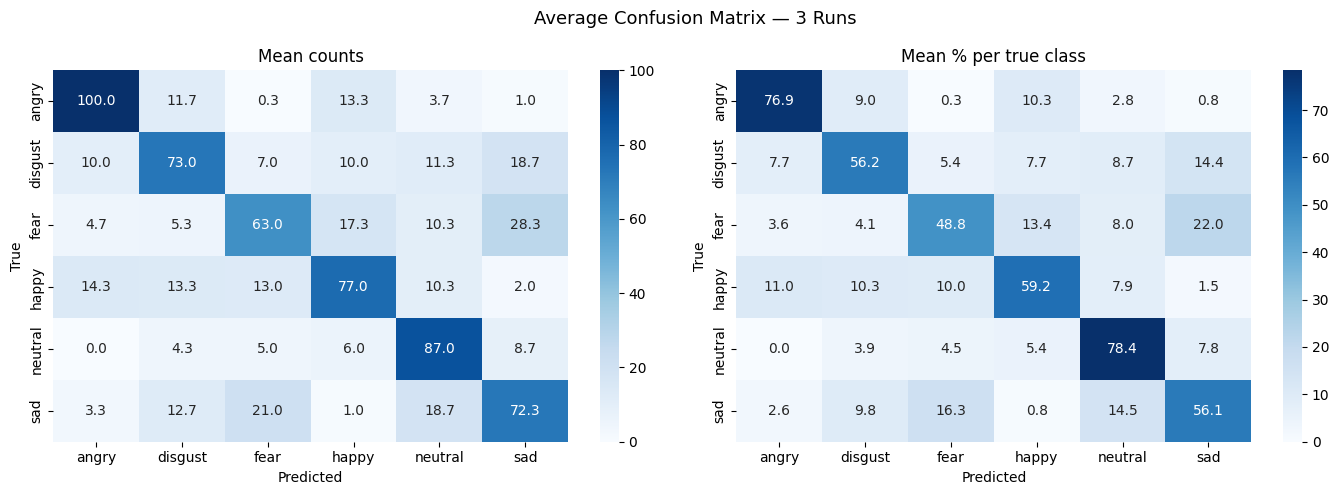

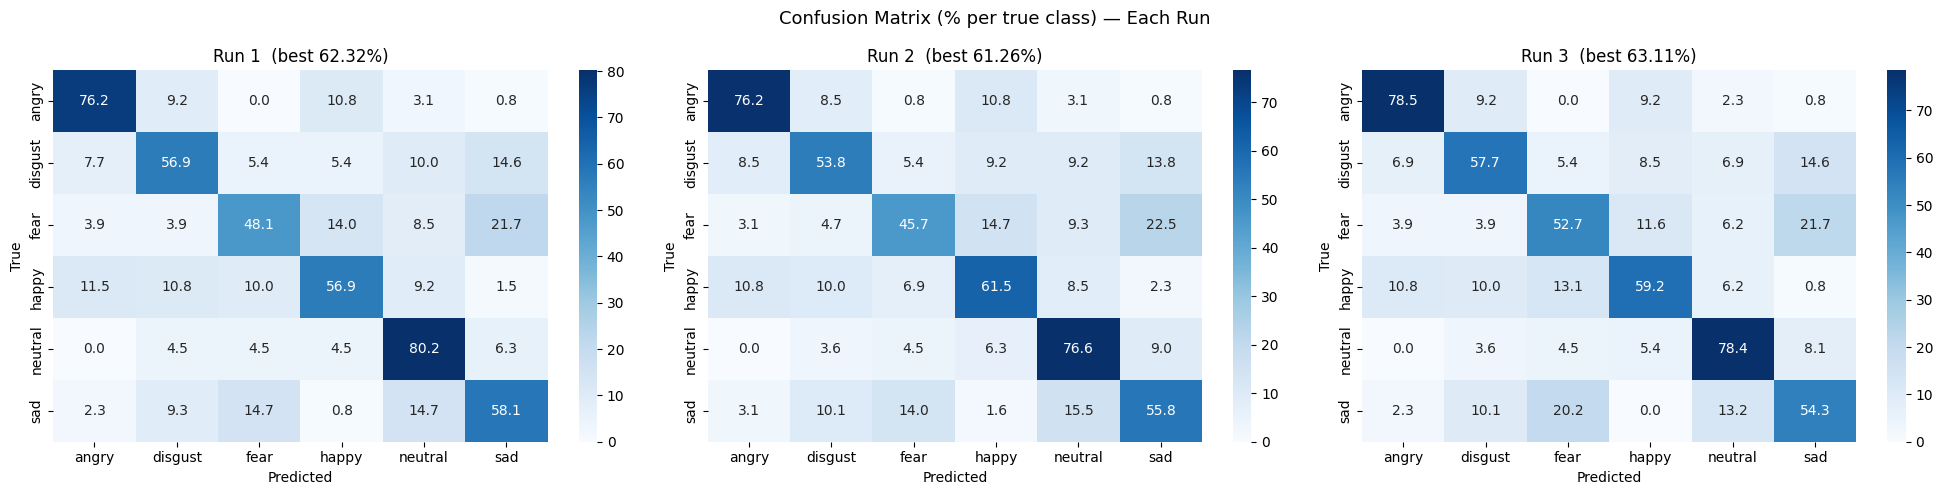

In [14]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

COMPILE_DIR = "/content/drive/MyDrive/cremad_checkpoints"
CLASS_NAMES = ["angry", "disgust", "fear", "happy", "neutral", "sad"]  # adjust if needed
N_RUNS = 3

all_histories, all_cms, all_best_accs, all_peak_epochs, all_final_accs = [], [], [], [], []

for run_id in range(1, N_RUNS + 1):
    run_dir = os.path.join(COMPILE_DIR, f"run{run_id}")

    with open(os.path.join(run_dir, f"run{run_id}_history.json")) as f:
        data = json.load(f)
    all_histories.append(data["history"])
    all_best_accs.append(data["best_val_acc"])
    all_peak_epochs.append(data["peak_epoch"])
    all_final_accs.append(data["final_acc"])

    cm = np.load(os.path.join(run_dir, f"run{run_id}_confusion_matrix.npy"))
    all_cms.append(cm)

    print(f"Run {run_id} loaded — best: {data['best_val_acc']:.2%} at epoch {data['peak_epoch']}")

print(f"\n{'='*55}")
print("ALL 3 RUNS")
print(f"{'='*55}")
print(f"\n  {'Run':<6} {'Best acc':>10} {'Peak epoch':>12} {'Final acc':>12}")
print(f"  {'-'*44}")
for i in range(N_RUNS):
    print(f"  Run {i+1:<3} {all_best_accs[i]:>10.2%} {all_peak_epochs[i]:>12} {all_final_accs[i]:>12.2%}")

print(f"\n  Best val accuracy  — mean: {np.mean(all_best_accs):.2%}  ± std: {np.std(all_best_accs):.2%}")
print(f"  Final val accuracy — mean: {np.mean(all_final_accs):.2%}  ± std: {np.std(all_final_accs):.2%}")
print(f"  Peak epoch         — mean: {np.mean(all_peak_epochs):.1f}   ± std: {np.std(all_peak_epochs):.1f}")
print(f"{'='*55}")

colors = ["#E76F51", "#4A90D9", "#2ecc71"]
fig, ax = plt.subplots(figsize=(12, 5))
for i, h in enumerate(all_histories):
    epochs = range(1, len(h["val_acc"]) + 1)
    ax.plot(epochs, [a * 100 for a in h["val_acc"]],
            color=colors[i], linewidth=2,
            label=f"Run {i+1}  (best {all_best_accs[i]:.2%})")
    ax.axhline(all_best_accs[i] * 100, color=colors[i],
               linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val Accuracy (%)")
ax.set_title("Validation Accuracy — All 3 Runs")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMPILE_DIR, "compiled_all_runs.png"), dpi=150)
plt.show()

min_len    = min(len(h["val_acc"]) for h in all_histories)
val_matrix = np.array([h["val_acc"][:min_len] for h in all_histories]) * 100
mean_curve = val_matrix.mean(axis=0)
std_curve  = val_matrix.std(axis=0)
epochs     = range(1, min_len + 1)

fig, ax = plt.subplots(figsize=(12, 5))
for i, h in enumerate(all_histories):
    ax.plot(range(1, min_len + 1), [a * 100 for a in h["val_acc"][:min_len]],
            color=colors[i], linewidth=1, alpha=0.3, linestyle="--",
            label=f"Run {i+1}")
ax.plot(epochs, mean_curve, color="#8B5CF6", linewidth=2.5,
        label=f"Mean ({np.mean(all_best_accs):.2%})")
ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                color="#8B5CF6", alpha=0.15,
                label=f"± 1 std ({np.std(all_best_accs):.2%})")
peak_idx = np.argmax(mean_curve)
ax.axvline(peak_idx + 1, color="#8B5CF6", linewidth=1, linestyle=":",
           alpha=0.8, label=f"Mean peak (ep {peak_idx+1})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val Accuracy (%)")
ax.set_title("Validation Accuracy — Mean ± Std (plateau visible)")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMPILE_DIR, "compiled_mean_std.png"), dpi=150)
plt.show()

mean_cm     = np.mean(all_cms, axis=0)
mean_cm_pct = mean_cm / mean_cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Average Confusion Matrix — 3 Runs", fontsize=13)

sns.heatmap(mean_cm, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Mean counts"); axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(mean_cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Mean % per true class"); axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(os.path.join(COMPILE_DIR, "compiled_avg_confusion_matrix.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Confusion Matrix (% per true class) — Each Run", fontsize=13)
for i, cm in enumerate(all_cms):
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i])
    axes[i].set_title(f"Run {i+1}  (best {all_best_accs[i]:.2%})")
    axes[i].set_ylabel("True"); axes[i].set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(COMPILE_DIR, "compiled_runs_side_by_side.png"), dpi=150)
plt.show()